# Bayesian Inference for CTR Estimation
### Prior → Likelihood → Posterior (Beta-Binomial Model)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Simulate real-world CTR data (or load from UCI)
# True underlying CTR we're trying to infer
true_ctr = 0.27  

# Observed data: 1 = clicked, 0 = didn't click
n_observations = 100
data = np.random.binomial(1, true_ctr, n_observations)

n_clicks = data.sum()
n_total = len(data)
print(f"Observed: {n_clicks} clicks out of {n_total} impressions")
print(f"MLE estimate: {n_clicks/n_total:.3f}")

Observed: 25 clicks out of 100 impressions
MLE estimate: 0.250


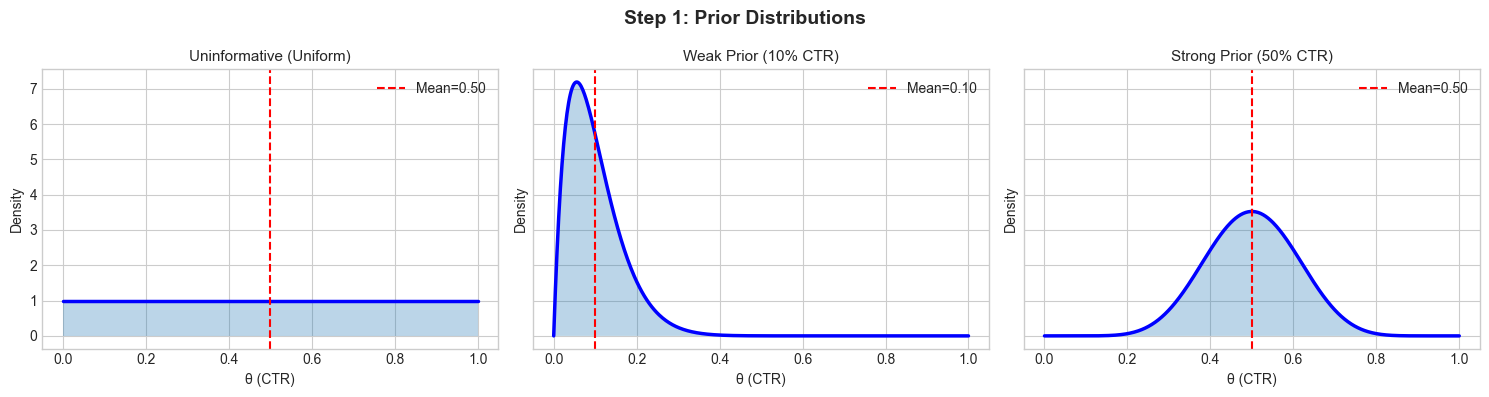

In [4]:
# Prior beliefs BEFORE seeing data
# Beta(α, β) → mean = α / (α + β)

priors = {
    "Uninformative (Uniform)": stats.beta(1, 1),       # flat prior
    "Weak Prior (10% CTR)":    stats.beta(2, 18),      # slight belief CTR ~10%
    "Strong Prior (50% CTR)":  stats.beta(10, 10),     # strong belief CTR ~50%
}

theta = np.linspace(0, 1, 500)  # possible CTR values

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, prior) in zip(axes, priors.items()):
    ax.plot(theta, prior.pdf(theta), 'b-', lw=2.5)
    ax.fill_between(theta, prior.pdf(theta), alpha=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("θ (CTR)")
    ax.set_ylabel("Density")
    mean = prior.mean()
    ax.axvline(mean, color='red', linestyle='--', label=f'Mean={mean:.2f}')
    ax.legend()
plt.suptitle("Step 1: Prior Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("prior.png", dpi=150)
plt.show()

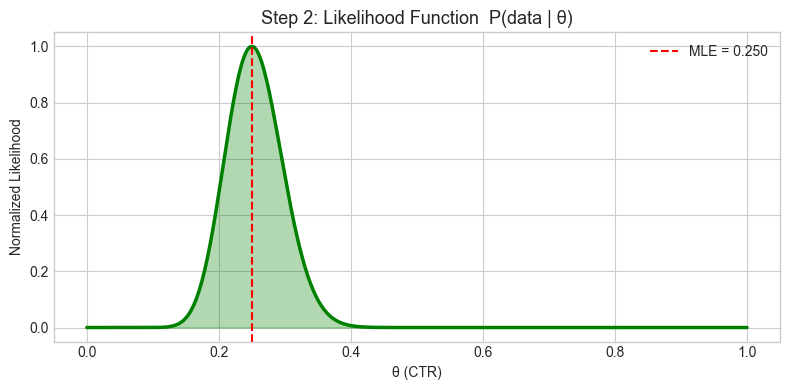

In [5]:
# Likelihood: P(data | θ) = Binomial
# For each possible θ, how likely is our observed data?

likelihoods = stats.binom.pmf(n_clicks, n_total, theta)
likelihoods /= likelihoods.max()  # normalize for plotting

plt.figure(figsize=(8, 4))
plt.plot(theta, likelihoods, 'g-', lw=2.5)
plt.fill_between(theta, likelihoods, alpha=0.3, color='green')
plt.axvline(n_clicks/n_total, color='red', linestyle='--',
            label=f'MLE = {n_clicks/n_total:.3f}')
plt.title("Step 2: Likelihood Function  P(data | θ)", fontsize=13)
plt.xlabel("θ (CTR)")
plt.ylabel("Normalized Likelihood")
plt.legend()
plt.tight_layout()
plt.savefig("likelihood.png", dpi=150)
plt.show()

In [6]:
alpha_prior = 2   # from "Weak Prior" above
beta_prior  = 18

# Bayesian update — conjugate formula
alpha_post = alpha_prior + n_clicks
beta_post  = beta_prior  + (n_total - n_clicks)

posterior = stats.beta(alpha_post, beta_post)
prior_dist = stats.beta(alpha_prior, beta_prior)

print(f"Prior:     Beta({alpha_prior}, {beta_prior})  → mean = {prior_dist.mean():.3f}")
print(f"Posterior: Beta({alpha_post}, {beta_post})  → mean = {posterior.mean():.3f}")
print(f"95% Credible Interval: [{posterior.ppf(0.025):.3f}, {posterior.ppf(0.975):.3f}]")

Prior:     Beta(2, 18)  → mean = 0.100
Posterior: Beta(27, 93)  → mean = 0.225
95% Credible Interval: [0.155, 0.304]


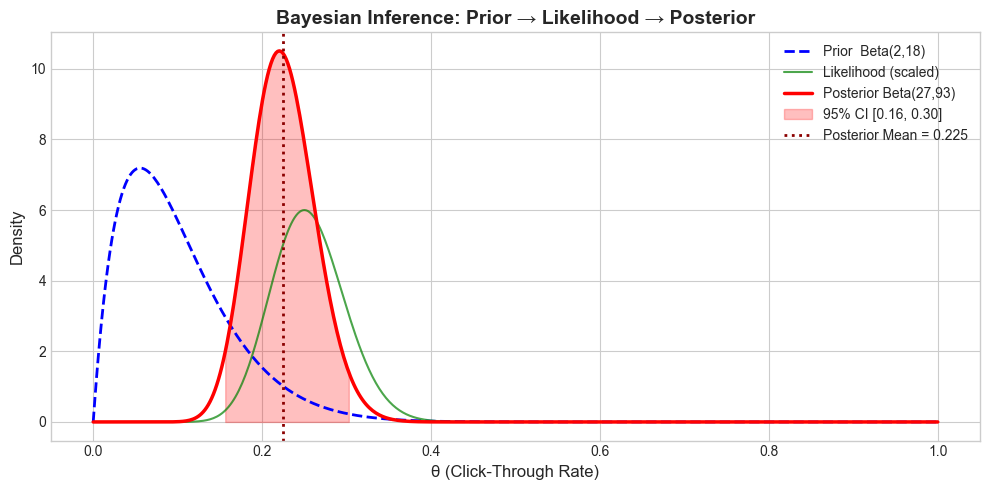

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(theta, prior_dist.pdf(theta),   'b--', lw=2,   label=f'Prior  Beta({alpha_prior},{beta_prior})')
ax.plot(theta, likelihoods * 6,          'g-',  lw=1.5, label='Likelihood (scaled)', alpha=0.7)
ax.plot(theta, posterior.pdf(theta),    'r-',  lw=2.5, label=f'Posterior Beta({alpha_post},{beta_post})')

# Credible interval
ci_low, ci_high = posterior.ppf(0.025), posterior.ppf(0.975)
ax.fill_between(theta,
                posterior.pdf(theta),
                where=(theta >= ci_low) & (theta <= ci_high),
                alpha=0.25, color='red', label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')

ax.axvline(posterior.mean(), color='darkred', linestyle=':', lw=2,
           label=f'Posterior Mean = {posterior.mean():.3f}')

ax.set_xlabel("θ (Click-Through Rate)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Bayesian Inference: Prior → Likelihood → Posterior", fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("bayesian_inference.png", dpi=150)
plt.show()

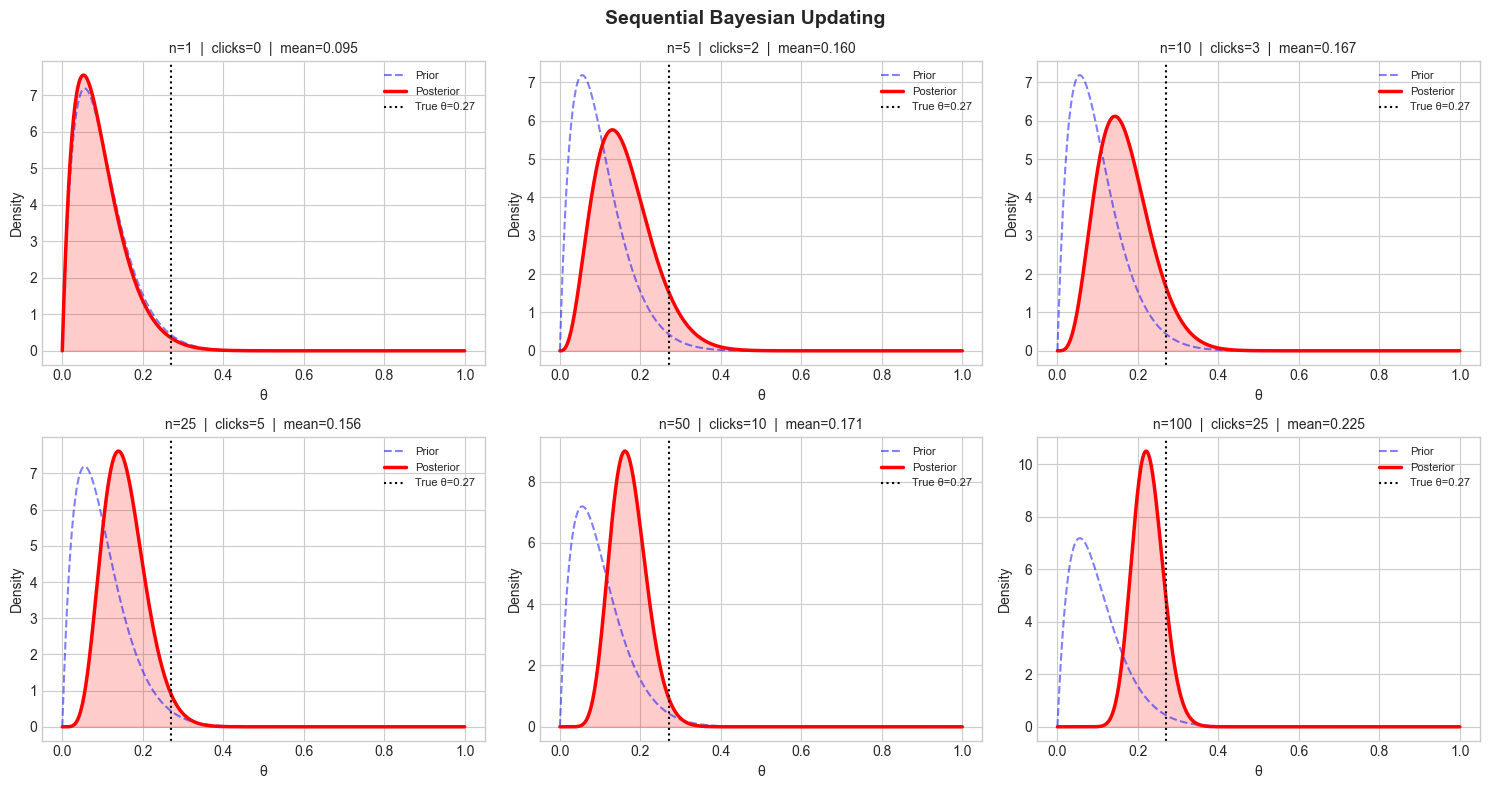

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

checkpoints = [1, 5, 10, 25, 50, 100]

for ax, n in zip(axes, checkpoints):
    subset = data[:n]
    clicks_so_far = subset.sum()
    
    a_post = alpha_prior + clicks_so_far
    b_post = beta_prior  + (n - clicks_so_far)
    post   = stats.beta(a_post, b_post)
    
    ax.plot(theta, prior_dist.pdf(theta), 'b--', lw=1.5, alpha=0.5, label='Prior')
    ax.plot(theta, post.pdf(theta),       'r-',  lw=2.5,             label=f'Posterior')
    ax.axvline(true_ctr, color='black', linestyle=':', lw=1.5, label=f'True θ={true_ctr}')
    ax.fill_between(theta, post.pdf(theta), alpha=0.2, color='red')
    
    ax.set_title(f"n={n}  |  clicks={clicks_so_far}  |  mean={post.mean():.3f}", fontsize=10)
    ax.set_xlabel("θ")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Sequential Bayesian Updating", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("sequential_update.png", dpi=150)
plt.show()

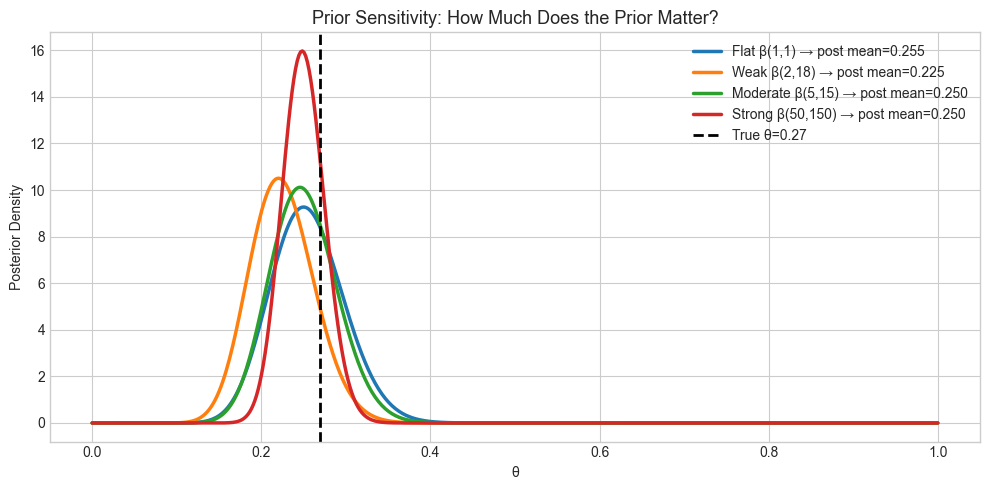

In [9]:
priors_to_compare = {
    "Flat β(1,1)":        stats.beta(1,  1),
    "Weak β(2,18)":       stats.beta(2,  18),
    "Moderate β(5,15)":   stats.beta(5,  15),
    "Strong β(50,150)":   stats.beta(50, 150),
}

plt.figure(figsize=(10, 5))
for name, pr in priors_to_compare.items():
    a_post = pr.args[0] + n_clicks
    b_post = pr.args[1] + (n_total - n_clicks)
    po = stats.beta(a_post, b_post)
    plt.plot(theta, po.pdf(theta), lw=2.5, label=f'{name} → post mean={po.mean():.3f}')

plt.axvline(true_ctr, color='black', linestyle='--', lw=2, label=f'True θ={true_ctr}')
plt.xlabel("θ")
plt.ylabel("Posterior Density")
plt.title("Prior Sensitivity: How Much Does the Prior Matter?", fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig("sensitivity.png", dpi=150)
plt.show()

In [10]:
print("=" * 60)
print(f"{'BAYESIAN INFERENCE SUMMARY':^60}")
print("=" * 60)
print(f"Dataset:        {n_total} ad impressions")
print(f"Observed clicks:{n_clicks}  ({n_clicks/n_total:.1%})")
print(f"Prior:          Beta({alpha_prior}, {beta_prior})  [mean={prior_dist.mean():.3f}]")
print(f"Posterior:      Beta({alpha_post}, {beta_post})  [mean={posterior.mean():.3f}]")
print(f"MAP Estimate:   {(alpha_post-1)/(alpha_post+beta_post-2):.3f}")
print(f"95% Cred. Int:  [{posterior.ppf(0.025):.3f},  {posterior.ppf(0.975):.3f}]")
print(f"Posterior Std:  {posterior.std():.4f}")
print("=" * 60)

                 BAYESIAN INFERENCE SUMMARY                 
Dataset:        100 ad impressions
Observed clicks:25  (25.0%)
Prior:          Beta(2, 18)  [mean=0.100]
Posterior:      Beta(27, 93)  [mean=0.225]
MAP Estimate:   0.220
95% Cred. Int:  [0.155,  0.304]
Posterior Std:  0.0380


## 7. Key Takeaways (XAI Perspective)

Bayesian inference is inherently interpretable:

- The **prior** encodes domain knowledge
- The **likelihood** represents observed evidence
- The **posterior** combines both to form updated beliefs

Unlike point estimates, Bayesian models:
- Provide **uncertainty (credible intervals)**
- Support **sequential learning**
- Allow **transparent reasoning**

This makes Bayesian inference a natural fit for Explainable AI (XAI).